In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from tqdm import tqdm
from pathlib import Path
import anndata as ad
import gc

In [2]:
# Load data, backed = r (read only) to save memory. 
# to not load the entire thing to ram and crash my cpu
input_path = "cd8_raw.h5ad"
adata = sc.read_h5ad(input_path, backed="r")
obs = adata.obs.copy()

Doing some exploration of data file

In [3]:
print("AnnData Object")
print(adata)
print("\n")

print("OBS (Cell Metadata) Info")
obs.info()
print("\n")

print("OBS Head")
print(obs.head())
print("\n")

print("Quick Categorical Value Counts (<50 unique)")
for col in obs.columns:
    if obs[col].nunique() < 50:
        print(f"\n[{col}]")
        print(obs[col].value_counts(dropna=False).head(10))

print("\nVAR (Gene Metadata) Head")
print(adata.var.head())

print("\nUnstructured Data Keys")
print(list(adata.uns.keys()) if adata.uns else "Empty")

AnnData Object
AnnData object with n_obs × n_vars = 717559 × 18063 backed at 'cd8_raw.h5ad'
    obs: 'cohort.cohortGuid', 'subject.subjectGuid', 'sample.sampleKitGuid', 'specimen.specimenGuid', 'subject.ageAtFirstDraw', 'subject.race', 'subject.ethnicity', 'subject.cmv', 'sample.visitName', 'sample.subjectAgeAtDraw', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_reads', 'n_umis', 'n_genes', 'total_counts_mito', 'pct_counts_mito', 'doublet_score', 'AIFI_L1', 'predicted_AIFI_L1', 'AIFI_L2', 'predicted_AIFI_L2', 'AIFI_L3', 'predicted_AIFI_L3', 'tissue_ontology_term_id', 'tissue_type', 'suspension_type', 'assay_ontology_term_id', 'sex_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_symbols', 'feature_is_filtered', 'f

### Pre filter distribution

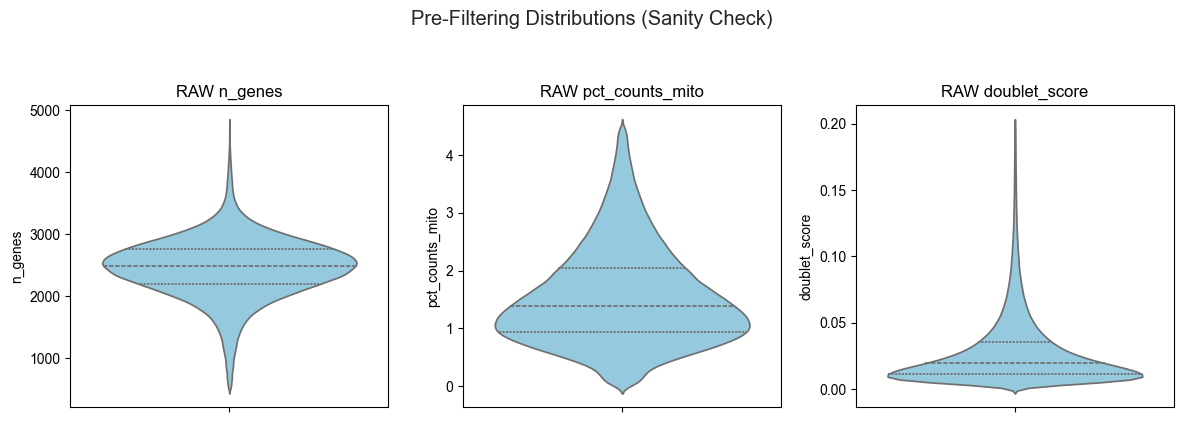

Raw Metadata Summary
          n_genes  pct_counts_mito  doublet_score
mean  2454.416431         1.558414       0.028759
50%   2486.000000         1.389365       0.019737
max   4789.000000         4.500000       0.199352


In [4]:
# Metrics we actually care about for filtering
metrics = ["n_genes", "pct_counts_mito", "doublet_score"]
pre_plot_df = obs[metrics].copy()

# Downsampling to 500k for performance
if len(pre_plot_df) > 500000:
    pre_plot_df = pre_plot_df.sample(500000, random_state=7)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sns.set_theme(style="whitegrid")

for i, metric in enumerate(metrics):
    sns.violinplot(y=pre_plot_df[metric], ax=axes[i], color="skyblue", inner="quartile")
    axes[i].set_title(f"RAW {metric}")
    
plt.suptitle("Pre-Filtering Distributions (Sanity Check)", y=1.05)
plt.tight_layout()
plt.show()

print("Raw Metadata Summary")
print(obs[metrics].describe().loc[['mean', '50%', 'max']])

### Apply QC Masks, Removing lower counts and filtering based on gene and cells

In [5]:
mask = pd.Series(True, index=obs.index)
start_n = len(obs)
print(f"Starting off with {start_n} total cells.")

# Ethnicity Filter
eth = obs["self_reported_ethnicity"].astype(str).str.strip().str.lower()
mask &= obs["self_reported_ethnicity"].notna() & (eth != "unknown")
print(f"Filtered out 'unknown' ethnicities... lost {start_n - mask.sum()} cells. {mask.sum()} left.")

prev_n = mask.sum()

# CMV Status Filter (Keep only definitive Positive/Negative)
mask &= obs["subject.cmv"].isin(["Positive", "Negative"])
print(f"Kept only Pos/Neg CMV cases. Lost another {prev_n - mask.sum()}. Down to {mask.sum()}.")

Starting off with 717559 total cells.
Filtered out 'unknown' ethnicities... lost 382049 cells. 335510 left.
Kept only Pos/Neg CMV cases. Lost another 3128. Down to 332382.


In [6]:
# Genes and Doublet Filter
prev_n = mask.sum()

mask &= obs["n_genes"] >= 1000
mask &= obs["n_genes"] <= 3900
print(f"Applying min 2000 genes cutoff: lost {prev_n - mask.sum()} cells. {mask.sum()} left.")

prev_n = mask.sum()

mask &= obs["doublet_score"].astype(float) < 0.1
print(f"Scrubbing doublets (score < 0.1): dropped {prev_n - mask.sum()} cells. {mask.sum()} remaining.")

# Mitochondrial filter
prev_n = mask.sum()
mask &= obs["pct_counts_mito"].astype(float) <= 3.8
print(f"Dropped {prev_n - mask.sum()} cells for high mito content.")

Applying min 2000 genes cutoff: lost 5289 cells. 327093 left.
Scrubbing doublets (score < 0.1): dropped 11119 cells. 315974 remaining.
Dropped 4450 cells for high mito content.


In [7]:
# checking cell type count after all QC to finally filter rare cell types
obs_before = obs.loc[mask].copy()
print(obs_before["cell_type"].value_counts().head(35))

cell_type
effector memory CD8-positive, alpha-beta T cell         164652
naive thymus-derived CD8-positive, alpha-beta T cell     78172
mature gamma-delta T cell                                32066
mucosal invariant T cell                                 24969
central memory CD8-positive, alpha-beta T cell            6715
double negative thymocyte                                 4158
CD8aa(I) thymocyte                                         648
CD8-positive, alpha-beta memory T cell                     144
Name: count, dtype: int64


In [8]:
# removing rare cell types
final_counts = obs.loc[mask, "cell_type"].value_counts()
keep_final_types = final_counts[final_counts >= 4000].index

prev_n = mask.sum()
mask &= obs["cell_type"].isin(keep_final_types)
print(f"Cleaned up {prev_n - mask.sum()} cells from types that became too rare after filtering.")

# Finalize the subset
obs_filtered = obs.loc[mask].copy()

print(f"\nFINAL SURVIVORS: {mask.sum()} / {start_n} ({mask.sum()/start_n*100:.1f}%)")

# Final Checks
print("\nFinal CMV Breakdown:")
print(obs_filtered["subject.cmv"].value_counts())

print("\nFinal Ethnicity Breakdown:")
print(obs_filtered["self_reported_ethnicity"].value_counts())

print("\nFinal Cell Type Breakdown (Top 20):")
print(obs_filtered["cell_type"].value_counts().head(20))

Cleaned up 792 cells from types that became too rare after filtering.

FINAL SURVIVORS: 310732 / 717559 (43.3%)

Final CMV Breakdown:
subject.cmv
Positive     213858
Negative      96874
Equivocal         0
Name: count, dtype: int64

Final Ethnicity Breakdown:
self_reported_ethnicity
Asian                164549
Hispanic or Latin    106585
African American      28753
Native American        8332
Pacific Islander       2513
unknown                   0
Name: count, dtype: int64

Final Cell Type Breakdown (Top 20):
cell_type
effector memory CD8-positive, alpha-beta T cell         164652
naive thymus-derived CD8-positive, alpha-beta T cell     78172
mature gamma-delta T cell                                32066
mucosal invariant T cell                                 24969
central memory CD8-positive, alpha-beta T cell            6715
double negative thymocyte                                 4158
CD8-positive, alpha-beta memory T cell                       0
CD8aa(I) thymocyte                

Post QC Visualize Metrics

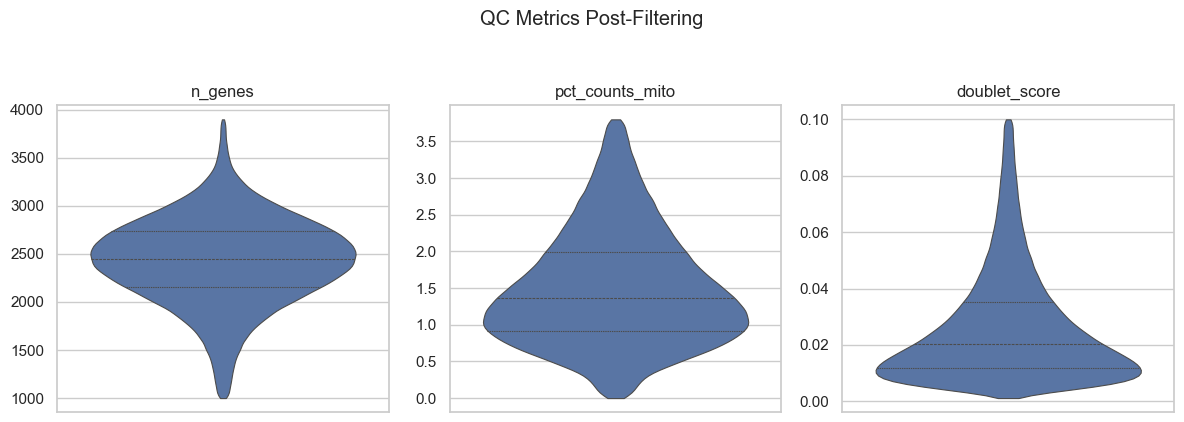

In [9]:
metrics = ["n_genes", "pct_counts_mito", "doublet_score"]
plot_df = obs_filtered[metrics].copy()

# Downsampling to 500k for performance
if len(plot_df) > 500000:
    plot_df = plot_df.sample(500000, random_state=7)

# Subplots for 3 metrics
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sns.set_theme(style="whitegrid")

for i, metric in enumerate(metrics):
    sns.violinplot(y=plot_df[metric], ax=axes[i], inner="quartile", cut=0, linewidth=0.8)
    axes[i].set_title(metric)
    axes[i].set_ylabel("")

plt.suptitle("QC Metrics Post-Filtering", y=1.05)
plt.tight_layout()
plt.show()

### Donor Split (Train/Val/Test : 70/15/15) based on donors

In [10]:
# Get unique donors from high-quality filtered set
donors = np.array(sorted(obs_filtered["donor_id"].dropna().unique()))
rng = np.random.default_rng(7)
rng.shuffle(donors)

# Define the 70/15/15 split points
n_donors = len(donors)
train_n = int(np.floor(0.70 * n_donors))
val_n = int(np.floor(0.15 * n_donors))

train_donors = donors[:train_n]
val_donors = donors[train_n : train_n + val_n]
test_donors = donors[train_n + val_n :]

# Create the mapping
split_map = {d: "train" for d in train_donors}
split_map.update({d: "val" for d in val_donors})
split_map.update({d: "test" for d in test_donors})

# Map back to the filtered metadata first
obs_filtered["split"] = obs_filtered["donor_id"].map(split_map)

# Create full dataset split mask
split_full = pd.Series("drop", index=obs.index)
split_full.loc[obs_filtered.index] = obs_filtered["split"]
print(split_full.value_counts())

drop     406827
train    198974
test      58146
val       53612
Name: count, dtype: int64


#### Normalize, Select HVGs only on train dataset

In [11]:
# Isolate Training Indices
train_mask = (split_full == "train").to_numpy()
val_mask = (split_full == "val").to_numpy()
test_mask = (split_full == "test").to_numpy()

train_idx_all = np.flatnonzero(train_mask)

# Subsample 50% of the training set for HVG calculation
n_hvg_subsample = len(train_idx_all) // 2
rng = np.random.default_rng(7)  # Consistency is key
hvg_subsample_idx = rng.choice(train_idx_all, size=n_hvg_subsample, replace=False)
hvg_subsample_idx.sort()  # Sorting for HDF5 performance

print(f"\nLoading 50% of Training set ({len(hvg_subsample_idx)} cells) for HVG calculation.")

# Load only the 50% subsample into RAM to find HVGs
train_hvg_adata = adata[hvg_subsample_idx, :].to_memory()

sc.pp.normalize_total(train_hvg_adata, target_sum=1e4)
sc.pp.log1p(train_hvg_adata)

# Calculate HVGs on the 50% Training Set
print("Calculating Highly Variable Genes across the 50% Training subsample.")
sc.pp.highly_variable_genes(train_hvg_adata, n_top_genes=2000, flavor="seurat")

# Extract the names and indices of the top 2000 HVGs
hvg_bool_mask = train_hvg_adata.var["highly_variable"].to_numpy()
hvg_names = train_hvg_adata.var_names[hvg_bool_mask]

# Store the global gene indices for pulling Val and Test later
hvg_idx = np.where(adata.var_names.isin(hvg_names))[0]

# Clean up the subsample matrix to make room for the full training extraction
del train_hvg_adata
gc.collect()

# Now extract the FULL training set but ONLY for the 2000 HVGs
print(f"Extracting all training cells ({len(train_idx_all)}) for the 2000 HVGs.")
train_idx_all.sort()
train_final = adata[train_idx_all, hvg_idx].to_memory()

# Normalize and Log the final training object
sc.pp.normalize_total(train_final, target_sum=1e4)
sc.pp.log1p(train_final)

print(f"Final Train Shape: {train_final.shape}")


Loading 50% of Training set (99487 cells) for HVG calculation.
Calculating Highly Variable Genes across the 50% Training subsample.
Extracting all training cells (198974) for the 2000 HVGs.
Final Train Shape: (198974, 2000)


In [12]:
# saving train set and deleting from memory

output_dir = Path("processed_data")
output_dir.mkdir(parents=True, exist_ok=True)
train_final.write(output_dir / "train.h5ad")

del train_final
gc.collect()

1572

#### sync val and test with train set, and preparing to save splits separately

In [14]:
val_idx = np.flatnonzero(val_mask)
test_idx = np.flatnonzero(test_mask)

print(f"Processing Val set ({len(val_idx)} cells)...")
# Load ONLY the 2000 HVGs from disk for the validation cells
val_adata = adata[val_idx, hvg_idx].to_memory()

sc.pp.normalize_total(val_adata, target_sum=1e4)
sc.pp.log1p(val_adata)

val_adata.write(output_dir / "val.h5ad")

del val_adata
gc.collect()


print(f"Processing Test set ({len(test_idx)} cells)...")
# Load ONLY the 2000 HVGs from disk for the test cells
test_adata = adata[test_idx, hvg_idx].to_memory()

sc.pp.normalize_total(test_adata, target_sum=1e4)
sc.pp.log1p(test_adata)

test_adata.write(output_dir / "test.h5ad")

del test_adata
gc.collect()

adata.file.close()
print("\nSuccess! All splits processed and saved independently. YAYYY")

Processing Val set (53612 cells)...
Processing Test set (58146 cells)...

Success! All splits processed and saved independently. YAYYY
